# 04 · Sampling Parameters

同一个 prompt，发两次给模型，结果往往不一样——这不是 bug，是设计如此。

模型输出的本质是一个**概率分布**，每次生成都是在这个分布上采样。
`temperature`、`top_p`、`top_k` 这三个参数控制的就是**怎么从这个分布里采样**。

理解它们，你就能精确控制模型输出的「随机性」与「创造力」。

## 1. 模型输出的本质：概率分布

每次生成 token 时，模型并不直接输出一个词，
而是输出词表中**每个 token 的概率**，然后按概率采样。

```
输入: "今天天气"
模型内部输出（logits → softmax）:
  "很好"   → 35%
  "不错"   → 28%
  "晴朗"   → 18%
  "糟糕"   →  8%
  其他词   → 11%
  ────────────────
  采样 → 每次结果可能不同
```

采样参数的作用：**改变这个分布的形状**，从而控制输出的多样性。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = ["Arial Unicode MS", "sans-serif"]

# 模拟一个简化的 logits 分布（5 个候选 token）
tokens  = ["很好", "不错", "晴朗", "糟糕", "一般"]
logits  = np.array([2.5, 2.1, 1.5, 0.8, 0.5])

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

probs = softmax(logits)
print("原始概率分布：")
for t, p in zip(tokens, probs):
    bar = "█" * int(p * 40)
    print(f"  {t}  {p:.3f}  {bar}")

原始概率分布：
  很好  0.424  ████████████████
  不错  0.284  ███████████
  晴朗  0.156  ██████
  糟糕  0.078  ███
  一般  0.057  ██


## 2. Temperature

Temperature 在 softmax 之前对 logits 做缩放：

$$P(token_i) = \frac{e^{logit_i / T}}{\sum_j e^{logit_j / T}}$$

- **T → 0**：分布极度尖锐，概率最高的 token 几乎必然被选中（贪心）
- **T = 1**：原始分布，不做任何改变
- **T > 1**：分布变平，低概率 token 也有机会被选中（更随机）

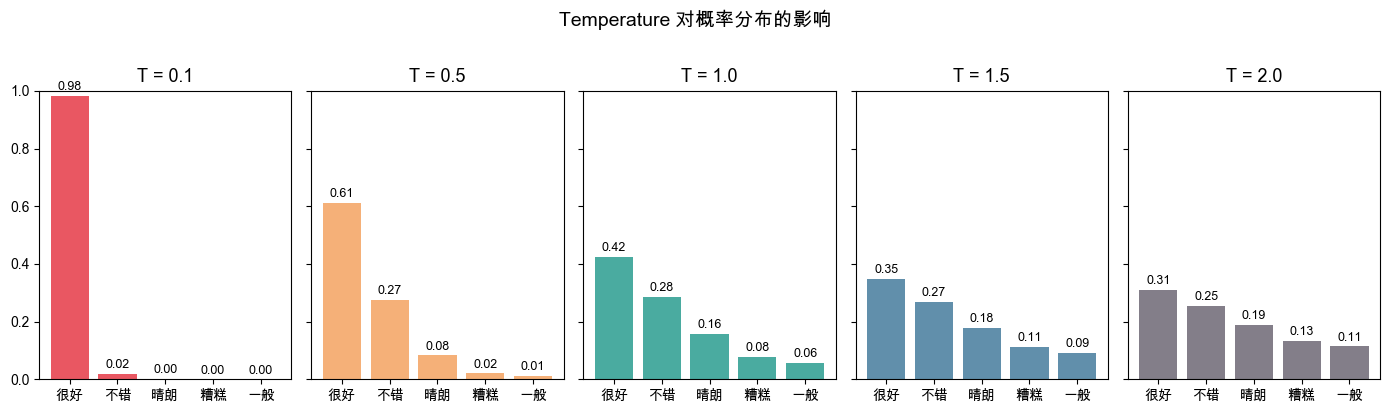

In [2]:
temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, len(temperatures), figsize=(14, 4), sharey=True)
colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#6D6875"]

for ax, T, color in zip(axes, temperatures, colors):
    p = softmax(logits / T)
    ax.bar(tokens, p, color=color, alpha=0.85)
    ax.set_title(f"T = {T}", fontsize=13)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=10)
    for i, v in enumerate(p):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

fig.suptitle("Temperature 对概率分布的影响", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
from utils.llm_client import chat

# 相同 prompt，不同 temperature，看输出变化
prompt = "用一句话描述秋天。"

print(f"Prompt: {prompt}\n")
for T in [0.0, 0.5, 1.0, 1.5]:
    # 每个 temperature 跑 2 次，观察稳定性
    results = [chat(prompt, temperature=T) for _ in range(2)]
    print(f"── Temperature = {T} ──")
    for i, r in enumerate(results, 1):
        print(f"  [{i}] {r.strip()}")
    print()

Prompt: 用一句话描述秋天。



── Temperature = 0.0 ──
  [1] 秋天是树叶由绿变金、微凉的风里夹着收获与别离气息的季节。
  [2] 秋天是金色阳光洒满大地、微凉秋风拂面、落叶与丰收交织出的宁静季节。



── Temperature = 0.5 ──
  [1] 秋天像一封写满金黄与微凉的信，悄悄把夏日的喧闹折叠成温柔的静好。
  [2] 秋天像位温柔的画家，把树叶染成金黄与火红，带来清冷的风与丰收的气息。



── Temperature = 1.0 ──
  [1] 秋天像披着金色披风的画家，把树叶染成黄与红，空气里带着果实的香甜与沁人心脾的凉意。
  [2] 秋天是微凉的风、金黄的田野与落叶在地上低语的季节。



── Temperature = 1.5 ──
  [1] 秋天像一幅金色的画卷，微凉的风带走暑热，落叶在脚下低语，空气里弥漫着丰收与思念的味道。
  [2] 秋天是阳光变得温柔、空气带着凉意与果实香甜、树叶在风中缓缓飘落的季节。



**观察：**
- `T=0`：两次输出几乎相同（确定性输出，适合代码生成、数学计算）
- `T=1`：有变化，但保持合理性
- `T=1.5`：更有创意，但可能出现不寻常的表达

## 3. Top-p（Nucleus Sampling）

Top-p 不直接操作 logits，而是**过滤候选集合**：

1. 把所有 token 按概率从高到低排序
2. 从头累加，直到累计概率 ≥ p
3. 只保留这些 token，重新归一化后采样

```
top_p = 0.9：
  "很好"  35%  ← 累计 35%
  "不错"  28%  ← 累计 63%
  "晴朗"  18%  ← 累计 81%
  "糟糕"   8%  ← 累计 89%
  "一般"   6%  ← 累计 95% > 90% ← 截止
  ────────────────────────────────
  只从前 4 个 token 中采样
```

**优点：** 候选集合大小随分布动态变化——分布集中时候选少，分布分散时候选多。

In [4]:
def apply_top_p(probs: np.ndarray, p: float) -> np.ndarray:
    """演示 top-p 过滤逻辑（仅用于理解原理）。"""
    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    cumulative = np.cumsum(sorted_probs)

    # 找到累计超过 p 的截止点
    cutoff = np.searchsorted(cumulative, p) + 1

    # 只保留前 cutoff 个
    mask = np.zeros_like(probs)
    mask[sorted_idx[:cutoff]] = probs[sorted_idx[:cutoff]]
    return mask / mask.sum()  # 重新归一化

print(f"{'Top-p':>8} | {'保留 token 数':>14} | 分布")
print("-" * 55)
for p in [0.5, 0.7, 0.9, 0.95, 1.0]:
    filtered = apply_top_p(probs, p)
    n_kept = (filtered > 0).sum()
    kept = [(tokens[i], filtered[i]) for i in range(len(tokens)) if filtered[i] > 0]
    kept_str = ", ".join(f"{t}({v:.2f})" for t, v in kept)
    print(f"{p:>8} | {n_kept:>14} | {kept_str}")

   Top-p |     保留 token 数 | 分布
-------------------------------------------------------
     0.5 |              2 | 很好(0.60), 不错(0.40)
     0.7 |              2 | 很好(0.60), 不错(0.40)
     0.9 |              4 | 很好(0.45), 不错(0.30), 晴朗(0.17), 糟糕(0.08)
    0.95 |              5 | 很好(0.42), 不错(0.28), 晴朗(0.16), 糟糕(0.08), 一般(0.06)
     1.0 |              5 | 很好(0.42), 不错(0.28), 晴朗(0.16), 糟糕(0.08), 一般(0.06)


In [5]:
# 实际 API：对比不同 top_p 的创意程度
prompt = "给一家咖啡店起一个有创意的名字，只给名字，不要解释。"

print(f"Prompt: {prompt}\n")
for p in [0.3, 0.7, 0.95]:
    results = [chat(prompt, temperature=1.0, top_p=p) for _ in range(3)]
    print(f"── top_p = {p} ──")
    for r in results:
        print(f"  {r.strip()}")
    print()

Prompt: 给一家咖啡店起一个有创意的名字，只给名字，不要解释。



── top_p = 0.3 ──
  豆蔻时光
  拾光咖啡馆
  午后拾光咖啡



── top_p = 0.7 ──
  夜光豆语
  豆间诗社
  豆间光年



── top_p = 0.95 ──
  豆间密语
  豆间物语
  豆间诗社



## 4. Top-k

Top-k 更简单粗暴：**固定只保留概率最高的 k 个 token**，不管概率分布形状如何。

```
top_k = 3：
  保留："很好"(35%)、"不错"(28%)、"晴朗"(18%)
  丢弃："糟糕"(8%)、"一般"(6%)
```

**缺点：** k 是固定的，无法适应分布的集中程度。
- 分布集中时（如 k=50 里 top-1 已有 90% 概率）：仍然采样 50 个，引入不必要的噪声
- 分布分散时（如 top-50 才覆盖 60%）：截断太早，错过合理候选

In [6]:
def apply_top_k(probs: np.ndarray, k: int) -> np.ndarray:
    """演示 top-k 过滤逻辑。"""
    top_k_idx = np.argsort(probs)[::-1][:k]
    mask = np.zeros_like(probs)
    mask[top_k_idx] = probs[top_k_idx]
    return mask / mask.sum()

print(f"{'Top-k':>8} | 保留的 token")
print("-" * 50)
for k in [1, 2, 3, 4, 5]:
    filtered = apply_top_k(probs, k)
    kept = [(tokens[i], filtered[i]) for i in range(len(tokens)) if filtered[i] > 0]
    kept_str = ", ".join(f"{t}({v:.2f})" for t, v in kept)
    print(f"{k:>8} | {kept_str}")

   Top-k | 保留的 token
--------------------------------------------------
       1 | 很好(1.00)
       2 | 很好(0.60), 不错(0.40)
       3 | 很好(0.49), 不错(0.33), 晴朗(0.18)
       4 | 很好(0.45), 不错(0.30), 晴朗(0.17), 糟糕(0.08)
       5 | 很好(0.42), 不错(0.28), 晴朗(0.16), 糟糕(0.08), 一般(0.06)


## 5. 三者的关系与实战建议

通常同时设置 temperature + top_p，**两个条件都满足才采样**：先用 top_p 过滤候选，再用 temperature 控制分布形状。

In [7]:
# 不同任务的推荐参数组合
presets = [
    {
        "场景": "代码生成 / 数学计算",
        "temperature": 0.0,
        "top_p": 1.0,
        "说明": "确定性输出，每次结果一致",
        "prompt": "写一个 Python 函数计算斐波那契数列第 n 项。",
    },
    {
        "场景": "信息提取 / 问答",
        "temperature": 0.3,
        "top_p": 0.9,
        "说明": "低随机性，保证准确，允许少量表达变化",
        "prompt": "Python 是哪年发布的？只回答年份。",
    },
    {
        "场景": "通用对话",
        "temperature": 0.7,
        "top_p": 0.95,
        "说明": "平衡创意与连贯性，API 默认值附近",
        "prompt": "给我讲一个关于程序员的笑话。",
    },
    {
        "场景": "创意写作 / 头脑风暴",
        "temperature": 1.2,
        "top_p": 0.95,
        "说明": "高随机性，鼓励新颖表达",
        "prompt": "用一句诗描述人工智能。",
    },
]

for preset in presets:
    print(f"\n{'='*55}")
    print(f"场景: {preset['场景']}")
    print(f"参数: temperature={preset['temperature']}, top_p={preset['top_p']}")
    print(f"说明: {preset['说明']}")
    print(f"Prompt: {preset['prompt']}")
    response = chat(
        preset["prompt"],
        temperature=preset["temperature"],
        top_p=preset["top_p"],
    )
    print(f"Output: {response.strip()}")


场景: 代码生成 / 数学计算
参数: temperature=0.0, top_p=1.0
说明: 确定性输出，每次结果一致
Prompt: 写一个 Python 函数计算斐波那契数列第 n 项。


Output: 下面给出几种常见的 Python 实现方式（默认采用 0 为第 0 项，1 为第 1 项，即 F(0)=0, F(1)=1）。函数都对非负整数 n 有效，若需 1 为第 1 项请把调用时的参数减 1 或调整说明。

1) 迭代（简单、推荐，一般用途）
```python
def fib_iter(n):
    if not isinstance(n, int) or n < 0:
        raise ValueError("n 必须是非负整数")
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a
```
复杂度：时间 O(n)，空间 O(1)。

2) 朴素递归（直观，但效率极低，仅用于教学）
```python
def fib_rec(n):
    if not isinstance(n, int) or n < 0:
        raise ValueError("n 必须是非负整数")
    if n < 2:
        return n
    return fib_rec(n-1) + fib_rec(n-2)
```
复杂度：时间约 O(2^n)，不推荐用于较大 n。

3) 快速幂/倍增法（用于大 n，时间 O(log n)）
```python
def fib_fast(n):
    if not isinstance(n, int) or n < 0:
        raise ValueError("n 必须是非负整数")
    # 返回 (F(n), F(n+1))
    def _fib_pair(k):
        if k == 0:
            return (0, 1)
        a, b = _fib_pair(k >> 1)
        c = a * (2 * b - a)      # F(2m)   = F(m) * (2*F(m+1) - F(m))
        d = a * a + b * b        # F(2m+1) = F(m)^2 + F(m+1)^2
        if k & 1:
            return (

Output: 1991

场景: 通用对话
参数: temperature=0.7, top_p=0.95
说明: 平衡创意与连贯性，API 默认值附近
Prompt: 给我讲一个关于程序员的笑话。


Output: 有两种程序员：懂二进制的，和不懂二进制的。

场景: 创意写作 / 头脑风暴
参数: temperature=1.2, top_p=0.95
说明: 高随机性，鼓励新颖表达
Prompt: 用一句诗描述人工智能。


Output: 冷光织梦，机器亦窥见人心。


In [8]:
# 极端参数演示：temperature=1.5 时输出会有多混乱
# 注意：temperature=2.0 有时会让模型生成纯空白 token，这里用 1.5 已足够极端
print("Temperature=1.5（极高随机性）的输出：")
for i in range(3):
    r = chat("今天天气很", temperature=1.5)
    out = r.strip()
    print(f"  [{i+1}] {out if out else repr(r)}")  # 空时显示原始内容帮助调试

Temperature=1.5（极高随机性）的输出：


  [1] 你好，你好像没把句子写完——"今天天气很..." 想说什么呢？

如果你需要提示，下面是几种常见续写和相应建议：
- 很好/晴朗：适合出门，别忘了防晒和带水。  
- 很热：多喝水、穿薄透气的衣服，尽量避开正午烈日。  
- 很冷：多穿几层，注意保暖和脚部防滑。  
- 很潮/下雨：带伞或雨具，穿防水鞋，出行注意路滑和交通延误。  
- 很闷/湿热：开空调或除湿机，注意防暑。  
- 有雾/沙尘：戴口罩，减少户外活动，开车注意能见度。

要不要我帮你查一下你所在城市的实时天气和预报？告诉我城市名（或允许定位）即可。


  [2] 你刚发了“今天天气很”还没写完。你是想让我帮你补全句子，还是要我查某个城市的实时天气？

如果要补全，这里是一些常见说法和对应建议：
- 今天天气很暖和/晴朗 —— 适合外出，带太阳镜、防晒。
- 今天天气很炎热 —— 注意防暑，多喝水、穿薄透气衣物。
- 今天天气很凉爽/清爽 —— 可以穿薄外套或长袖。
- 今天天气很阴沉/多云 —— 可能会阴天，外出可备轻便外套。
- 今天天气很湿冷/下雨 —— 带伞和防水外套，注意保暖。

如果要查天气，请告诉我城市或允许我使用你的位置，我马上为你查当天的预报和穿衣建议。


  [3] 你刚写到“今天天气很”，好像没写完。你是想说：

- 今天天气很好 / 晴朗  
- 今天天气很热  
- 今天天气很冷  
- 今天天气很潮 / 闷  
- 今天天气很阴 / 要下雨

想让我给出对应的建议吗？例如：

- 很热：多喝水、戴帽子/太阳镜、涂防晒、避开中午高温；室内空调26℃左右。  
- 很冷：多穿保暖、分层着装、戴帽手套，室内注意通风加湿。  
- 有雨：带伞/雨具、防水鞋，出行注意路滑。  
- 闷/潮湿：开除湿、通风，注意防霉。  
- 晴好：适合户外活动，注意防晒和空气质量。

要我查一下你所在城市的实时天气预报和穿衣/出行建议吗？告诉我城市名或开启位置即可。


## 小结

| 参数 | 作用 | 推荐范围 |
|------|------|----------|
| `temperature` | 缩放 logits，控制分布的尖锐程度 | 0（确定）→ 1.5（创意） |
| `top_p` | 动态过滤候选集，保留累计概率前 p 的 token | 0.9–0.95（通用） |
| `top_k` | 固定保留概率最高的 k 个 token | 通常不单独使用 |

**经验法则：**
- 精确任务（代码、计算、提取）→ `temperature=0`
- 通用对话 → `temperature=0.7, top_p=0.95`
- 创意任务 → `temperature=1.0–1.3, top_p=0.95`
- `temperature` 和 `top_p` 一起调，但**不要同时调 top_k**

---

**Module 1 · 基础概念 完结** 🎉

**下一模块 →** [Module 2: Prompting](../02_prompting/01_zero_few_shot.ipynb)：Zero-shot、Few-shot、Chain-of-Thought